In [2]:
# =======================================
# CARGAR E INGESTA DE DATOS
# =======================================

# ---------------------------------------
# LIBRERIAS
# ---------------------------------------

import gdown         # Descarga de archivos desde Google Drive
import pandas as pd  # Manipulación y análisis de datos
import os            # Manejo de sistema de archivos

# ---------------------------------------
# FUNCIÓN: CARGA DEL DATASET
# ---------------------------------------

def load_data(): 
    path = "../data/logs.csv"

    # --- Si No Existe Descargar En Carpeta De Data ---
    if not os.path.exists(path):
        url = "https://drive.google.com/uc?id=1JuQvmvIsmp965S4-Is8SQAIOnM-PN_CN"
        gdown.download(url, path, quiet=True)

    # --- Leer Dataset ---
    df = pd.read_csv(path)

    return df

# --- Obtener DataFrame ---
dataframe = load_data()

# --- Conversion De Timestamps ---
dataframe["timestamp_event"] = pd.to_datetime(dataframe["timestamp_event"])
dataframe["received_at"]     = pd.to_datetime(dataframe["received_at"])

# --- Vista Inicial ---
dataframe.head()
dataframe.shape

(5795, 15)

In [3]:
# =======================================
# INSPECCIÓN ESTRUCTURAL DEL DATASET
# =======================================

# --- Ver Columnas Disponibles ---
print("="*60)
print("Columnas:")
print(dataframe.columns.tolist())
print("="*60)
print()

# --- Ver Tipos De Datos ---
print("Tipos de datos:")
dataframe.info()

# --- Ver Estadisticas Descriptivas ---
print("="*60)
print("Estadísticas numéricas:")
dataframe.describe()

Columnas:
['timestamp_event', 'received_at', 'service_name', 'severity', 'message', 'trace_id', 'request_id', 'method', 'endpoint', 'status_code', 'latency_ms', 'host', 'env', 'region', 'log_type']

Tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5795 entries, 0 to 5794
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   timestamp_event  5795 non-null   datetime64[ns, UTC]
 1   received_at      5795 non-null   datetime64[ns, UTC]
 2   service_name     5795 non-null   object             
 3   severity         5795 non-null   object             
 4   message          5795 non-null   object             
 5   trace_id         5795 non-null   object             
 6   request_id       5795 non-null   object             
 7   method           5795 non-null   object             
 8   endpoint         5795 non-null   object             
 9   status_code      5795 non-null   in

,status_code,latency_ms
count,5795.000000,5795.000000
mean,256.041588,555.945815
std,114.044610,986.584842
min,200.000000,40.000000
25%,200.000000,111.000000
50%,200.000000,156.000000
75%,200.000000,557.500000
max,504.000000,13898.000000


In [4]:
# =======================================
# VALIDACIÓN DE CALIDAD DE DATOS
# =======================================

# ---------------------------------------
# VERIFICACION DE COLUMNAS OBLIGATORIAS
# ---------------------------------------
required_columns = [
    "timestamp_event", "received_at", "service_name",
    "severity", "message", "method",
    "endpoint", "status_code", "latency_ms", "trace_id"
]

# --- Verificar Cada Columna ---
missing = [col for col in required_columns if col not in dataframe.columns]

# --- Columnas faltantes ---
print("="*60)
print("Columnas faltantes:", missing)
print("="*60)

# --- Detectar Valores Nulos ---
print("Valores nulos por columna:")
print(dataframe.isnull().sum())
print("="*60)

# --- Validar Conversion De Timestamps ---
print("Ejemplo de timestamps:")
print(dataframe[["timestamp_event", "received_at"]].head())

Columnas faltantes: []
Valores nulos por columna:
timestamp_event    0
received_at        0
service_name       0
severity           0
message            0
trace_id           0
request_id         0
method             0
endpoint           0
status_code        0
latency_ms         0
host               0
env                0
region             0
log_type           0
dtype: int64
Ejemplo de timestamps:
                   timestamp_event                      received_at
0 2026-01-10 00:02:39.029160+00:00 2026-01-10 00:02:39.097160+00:00
1 2026-01-10 00:02:46.081021+00:00 2026-01-10 00:02:46.196021+00:00
2 2026-01-10 00:04:01.648849+00:00 2026-01-10 00:04:01.718849+00:00
3 2026-01-10 00:05:08.148346+00:00 2026-01-10 00:05:08.236346+00:00
4 2026-01-10 00:05:19.590837+00:00 2026-01-10 00:05:19.632837+00:00


In [14]:
# =======================================
# EXPLORACIÓN INICIAL DEL DATASET
# =======================================

# ---------------------------------------
# TOTAL DE LOGS
# ---------------------------------------

total_logs = len(dataframe)
print(f"Total de logs: {total_logs}")
print("="*60)

# ---------------------------------------
# DISTRIBUCIÓN DE SEVERIDAD
# ---------------------------------------
# Permite ver qué tan sano está el sistema

severity_counts = dataframe["severity"].value_counts()

print("Distribución de severidad:")
print(severity_counts)
print("="*60)

# ---------------------------------------
# SERVICIOS MÁS Y MENOS ACTIVOS
# ---------------------------------------

service_counts = dataframe["service_name"].value_counts()

print("Servicios más activos:")
print(service_counts.head())
print()

print("Servicios menos activos:")
print(service_counts.sort_values(ascending=True).head())
print("="*60)


Total de logs: 5795
Distribución de severidad:
severity
INFO        3542
WARN        1358
ERROR        775
CRITICAL     120
Name: count, dtype: int64
Servicios más activos:
service_name
api-gateway          1509
orders-service       1057
inventory-service     964
payment-service       842
auth-service          778
Name: count, dtype: int64

Servicios menos activos:
service_name
notification-service     645
auth-service             778
payment-service          842
inventory-service        964
orders-service          1057
Name: count, dtype: int64


In [7]:
# ---------------------------------------
# MENSAJES MÁS FRECUENTES
# ---------------------------------------

message_counts = dataframe["message"].value_counts()

print("Mensajes más frecuentes:")
print(message_counts.head())
print("="*60)

# ---------------------------------------
# MENSAJES 'MALOS' MÁS FRECUENTES
# ---------------------------------------
# Definimos eventos malos según reglas del challenge

bad_events = dataframe[
    (dataframe["severity"].isin(["ERROR", "CRITICAL"])) |
    (dataframe["status_code"] >= 500)
]

bad_message_counts = bad_events["message"].value_counts()

print("Mensajes malos más frecuentes:")
print(bad_message_counts.head())
print("="*60)

Mensajes más frecuentes:
message
Health check OK                                   1196
Background job completed                          1185
Request completed                                 1161
Order creation failed - inventory lock timeout     197
Rate limit nearing threshold                       193
Name: count, dtype: int64
Mensajes malos más frecuentes:
message
Order creation failed - inventory lock timeout    197
Payment gateway unavailable                       103
Database deadlock detected                         99
Checkout failed - upstream payment timeout         88
Possible credential stuffing detected              69
Name: count, dtype: int64


In [ ]:
# =======================================
# MODELADO TEMPORAL (BINS DE 5 MINUTOS)
# =======================================

# ---------------------------------------
# CREACIÓN DE VENTANAS TEMPORALES
# ---------------------------------------
# Redondea cada timestamp hacia abajo al bloque de 5 minutos

dataframe["window_start"] = dataframe["timestamp_event"].dt.floor("5min")

# ---------------------------------------
# EVENTOS POR VENTANA
# ---------------------------------------
# Conteo total de logs por cada ventana

events_per_window = dataframe.groupby("window_start").size()

print("="*60)
print("Eventos por ventana (primeras filas):")
print(events_per_window.head())
print("="*60)

# ---------------------------------------
# CONVERSIÓN A DATAFRAME (para análisis posterior)
# ---------------------------------------

events_per_window = events_per_window.reset_index(name="total_events")

print("Vista estructurada:")
print(events_per_window.head())

#“Hay variabilidad en el volumen de eventos por ventana, lo que indica cambios en la carga del sistema a lo largo del tiempo.”

Eventos por ventana (primeras filas):
window_start
2026-01-10 00:00:00+00:00    3
2026-01-10 00:05:00+00:00    4
2026-01-10 00:10:00+00:00    3
2026-01-10 00:15:00+00:00    4
2026-01-10 00:20:00+00:00    9
dtype: int64
Vista estructurada:
               window_start  total_events
0 2026-01-10 00:00:00+00:00             3
1 2026-01-10 00:05:00+00:00             4
2 2026-01-10 00:10:00+00:00             3
3 2026-01-10 00:15:00+00:00             4
4 2026-01-10 00:20:00+00:00             9


In [16]:
# =======================================
# DEFINICIÓN DE EVENTOS MALOS
# =======================================

# ---------------------------------------
# CREAR COLUMNA DE BAD EVENTS
# ---------------------------------------

dataframe["is_bad"] = (
    (dataframe["severity"].isin(["ERROR", "CRITICAL"])) |
    (dataframe["status_code"] >= 500)
)

# ---------------------------------------
# AGREGACIÓN POR VENTANA
# ---------------------------------------

window_metrics = dataframe.groupby("window_start").agg(
    total_events=("is_bad", "count"),
    bad_events=("is_bad", "sum")
).reset_index()

# ---------------------------------------
# CALCULAR BAD RATE
# ---------------------------------------

window_metrics["bad_rate"] = (
    window_metrics["bad_events"] / window_metrics["total_events"]
)

print(window_metrics.head())

               window_start  total_events  bad_events  bad_rate
0 2026-01-10 00:00:00+00:00             3           0  0.000000
1 2026-01-10 00:05:00+00:00             4           0  0.000000
2 2026-01-10 00:10:00+00:00             3           0  0.000000
3 2026-01-10 00:15:00+00:00             4           0  0.000000
4 2026-01-10 00:20:00+00:00             9           1  0.111111


In [ ]:
# =======================================
# DETECCIÓN DEL MOMENTO CRÍTICO
# =======================================

# ---------------------------------------
# FILTRAR VENTANAS CON SUFICIENTES EVENTOS
# ---------------------------------------

filtered_windows = window_metrics[
    window_metrics["total_events"] >= 20
]

# ---------------------------------------
# TOP 5 PEORES VENTANAS
# ---------------------------------------

top_windows = filtered_windows.sort_values(
    by="bad_rate", ascending=False
).head(10)

print("="*60)
print("Top 5 ventanas críticas:")
print(top_windows)
print("="*60)

# ---------------------------------------
# MOMENTO CRÍTICO (TOP 1)
# ---------------------------------------

critical_window = top_windows.iloc[0]

print("Momento crítico:")
print(critical_window)

#l sistema experimentó un incidente crítico el 2026-01-10 a las 11:10 UTC, alcanzando un bad_rate del 58%, lo que indica que más de la mitad de las requests fallaron. La degradación se mantuvo durante al menos 15 minutos consecutivos, lo que sugiere un problema sistémico sostenido en lugar de un pico aislado.

Top 5 ventanas críticas:
                 window_start  total_events  bad_events  bad_rate
134 2026-01-10 11:10:00+00:00           189         110  0.582011
135 2026-01-10 11:15:00+00:00           228         129  0.565789
136 2026-01-10 11:20:00+00:00           111          59  0.531532
462 2026-01-11 14:35:00+00:00           255         117  0.458824
461 2026-01-11 14:30:00+00:00           156          68  0.435897
460 2026-01-11 14:25:00+00:00           178          72  0.404494
686 2026-01-12 09:30:00+00:00           136          48  0.352941
688 2026-01-12 09:40:00+00:00           124          38  0.306452
687 2026-01-12 09:35:00+00:00           137          38  0.277372
Momento crítico:
window_start    2026-01-10 11:10:00+00:00
total_events                          189
bad_events                            110
bad_rate                         0.582011
Name: 134, dtype: object


In [26]:
# ===================================================
# FILTRAR MOMENTO CRÍTICO Y SERVICIOS MAS AFECTADOS
# ===================================================

# ---------------------------------
# MOMENTO CRITICO
# ---------------------------------

critical_time = critical_window["window_start"]

critical_data = dataframe[
    dataframe["window_start"] == critical_time
]


# ---------------------------------
# SERVICIOS MÁS AFECTADOS
# ---------------------------------

bad_critical = critical_data[
    critical_data["is_bad"]
]


# --- IMPRIMIR INFORMACION EN PANTALLAA ---

print("="*60)
print(f"Momento crítico: {critical_time}")
print(f"Total de eventos: {len(critical_data)}")
print(f"Eventos malos: {len(bad_critical)}")
print("="*60)

Momento crítico: 2026-01-10 11:10:00+00:00
Total de eventos: 189
Eventos malos: 110


In [ ]:
# =======================================
# DIAGNÓSTICO DEL INCIDENTE
# =======================================

# ---------------------------------------
# SERVICIOS MÁS AFECTADOS
# ---------------------------------------

print("\n" + "="*60)
print("SERVICIOS MÁS AFECTADOS")
print("="*60)

service_impact = bad_critical["service_name"].value_counts()
print(service_impact)

# ---------------------------------------
# MENSAJES DOMINANTES
# ---------------------------------------

print("\n" + "="*60)
print("MENSAJES DOMINANTES")
print("="*60)

message_impact = bad_critical["message"].value_counts()
print(message_impact.head())

# ---------------------------------------
# ENDPOINTS MÁS COMPROMETIDOS
# ---------------------------------------

print("\n" + "="*60)
print("ENDPOINTS MÁS COMPROMETIDOS")
print("="*60)

endpoint_impact = bad_critical["endpoint"].value_counts()
print(endpoint_impact.head())

# Diagnostico de datos:
"""# El incidente crítico ocurrido el 2026-01-10 a las 11:10 UTC estuvo concentrado principalmente en el orders-service, que generó la mayor cantidad de eventos fallidos (72), seguido por el inventory-service (37).
Los mensajes de error dominantes indican problemas de concurrencia, destacando “inventory lock timeout” y “database deadlock detected”. Esto sugiere una contención de recursos en el sistema de inventario, provocando bloqueos prolongados y conflictos entre transacciones.
Los endpoints más afectados pertenecen al flujo completo de órdenes (/orders/*) y operaciones de inventario (/inv/*), lo que indica una degradación sistémica del dominio de órdenes.
En conjunto, la evidencia sugiere que el incidente fue causado por saturación y conflictos concurrentes en el manejo de inventario, afectando directamente la capacidad del sistema para procesar órdenes."""


SERVICIOS MÁS AFECTADOS
service_name
orders-service       72
inventory-service    37
payment-service       1
Name: count, dtype: int64

MENSAJES DOMINANTES
message
Order creation failed - inventory lock timeout    72
Database deadlock detected                        37
External dependency error                          1
Name: count, dtype: int64

ENDPOINTS MÁS COMPROMETIDOS
endpoint
/orders/cancel    26
/orders/create    25
/orders/status    21
/inv/reserve      18
/inv/stock        13
Name: count, dtype: int64


In [ ]:
# =======================================
# COMPARACIÓN: INCIDENTE vs BASELINE
# =======================================

# ---------------------------------------
# BASELINE (todo excepto momento crítico)
# ---------------------------------------

baseline_data = dataframe[
    dataframe["window_start"] != critical_time
]

# ---------------------------------------
# MÉTRICAS INCIDENTE
# ---------------------------------------

incident_total = len(critical_data)
incident_bad_rate = len(bad_critical) / incident_total
incident_latency = critical_data["latency_ms"].mean()
incident_5xx = (critical_data["status_code"] >= 500).mean()

# ---------------------------------------
# MÉTRICAS BASELINE
# ---------------------------------------

baseline_total = len(baseline_data)

baseline_bad = baseline_data[
    (baseline_data["severity"].isin(["ERROR", "CRITICAL"])) |
    (baseline_data["status_code"] >= 500)
]

baseline_bad_rate = len(baseline_bad) / baseline_total
baseline_latency = baseline_data["latency_ms"].mean()
baseline_5xx = (baseline_data["status_code"] >= 500).mean()

# ---------------------------------------
# TABLA COMPARATIVA
# ---------------------------------------

comparison = pd.DataFrame({
    "metric": ["total_events", "bad_rate", "avg_latency_ms", "%_5xx"],
    "incident": [
        incident_total,
        incident_bad_rate,
        incident_latency,
        incident_5xx
    ],
    "baseline": [
        baseline_total,
        baseline_bad_rate,
        baseline_latency,
        baseline_5xx
    ]
})

print("="*60)
print("COMPARACIÓN INCIDENTE vs BASELINE")
print("="*60)
print(comparison)

# CONCLUSIÓN FINAL

"""El sistema experimentó un incidente crítico alrededor de las 11:10 UTC, donde el bad_rate aumentó de 14% en condiciones normales a 58% durante la ventana afectada. Este incremento estuvo acompañado por un aumento significativo en la latencia promedio (de ~521 ms a ~1589 ms), lo que indica una degradación severa del rendimiento.
El incremento en la tasa de errores 5xx confirma que no se trató de simples retardos, sino de fallos reales en la ejecución de requests
En conjunto, los datos evidencian un incidente de saturación y fallos en cascada en el sistema."""

COMPARACIÓN INCIDENTE vs BASELINE
           metric     incident     baseline
0    total_events   189.000000  5606.000000
1        bad_rate     0.582011     0.140029
2  avg_latency_ms  1589.687831   521.094363
3           %_5xx     0.582011     0.140029



GRÁFICO 1 → Evolución de severidad en el tiempo
Muestra cómo se distribuyen INFO / WARN / ERROR / CRITICAL
Permite detectar cuándo empieza la degradación del sistema


<Figure size 640x480 with 0 Axes>

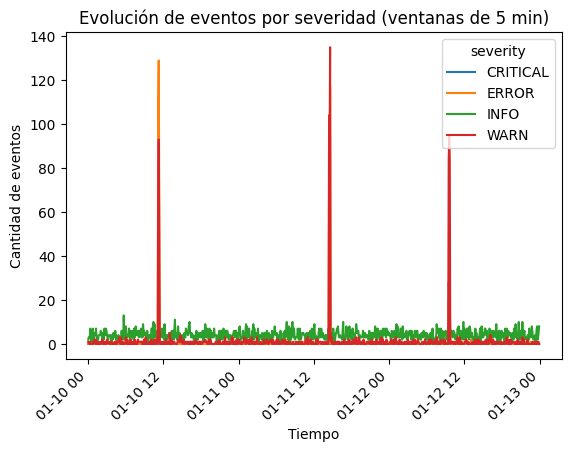


Interpretación:
- Si ERROR/CRITICAL suben → el sistema se degrada
- Si INFO domina → sistema estable


In [36]:
# =======================================
# VISUALIZACIÓN DEL SISTEMA (CON CONTEXTO)
# =======================================

import matplotlib.pyplot as plt

# ---------------------------------------
# PREPARACIÓN DE DATOS
# ---------------------------------------

severity_timeline = dataframe.groupby(
    ["window_start", "severity"]
).size().unstack(fill_value=0)

bad_rate_timeline = dataframe.groupby("window_start")["is_bad"].mean()

# =======================================
# GRÁFICO 1: SEVERIDAD EN EL TIEMPO
# =======================================

print("\n" + "="*60)
print("GRÁFICO 1 → Evolución de severidad en el tiempo")
print("Muestra cómo se distribuyen INFO / WARN / ERROR / CRITICAL")
print("Permite detectar cuándo empieza la degradación del sistema")
print("="*60)

plt.figure()

severity_timeline.plot()

plt.title("Evolución de eventos por severidad (ventanas de 5 min)")
plt.xlabel("Tiempo")
plt.ylabel("Cantidad de eventos")
plt.xticks(rotation=45)

plt.show()

print("\nInterpretación:")
print("- Si ERROR/CRITICAL suben → el sistema se degrada")
print("- Si INFO domina → sistema estable")




GRÁFICO 2 → Bad Rate a lo largo del tiempo
Muestra la proporción de eventos fallidos por ventana
Este gráfico detecta directamente el incidente


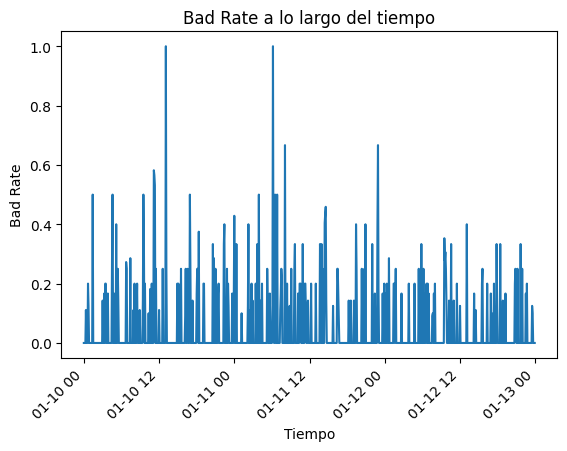


Interpretación:
- Picos altos = incidentes
- Línea estable baja = baseline del sistema
- El pico alrededor del incidente confirma la degradación


In [35]:
# =======================================
# GRÁFICO 2: BAD RATE EN EL TIEMPO
# =======================================

print("\n" + "="*60)
print("GRÁFICO 2 → Bad Rate a lo largo del tiempo")
print("Muestra la proporción de eventos fallidos por ventana")
print("Este gráfico detecta directamente el incidente")
print("="*60)

plt.figure()

bad_rate_timeline.plot()

plt.title("Bad Rate a lo largo del tiempo")
plt.xlabel("Tiempo")
plt.ylabel("Bad Rate")
plt.xticks(rotation=45)

plt.show()

print("\nInterpretación:")
print("- Picos altos = incidentes")
print("- Línea estable baja = baseline del sistema")
print("- El pico alrededor del incidente confirma la degradación")

In [49]:
# =======================================
# CONCLUSIONES FINALES DEL ANÁLISIS
# =======================================

print("="*60)
print("CONCLUSIONES FINALES")
print("="*60)

print("""
El sistema presentó un incidente crítico el 2026-01-10 11:10 UTC,\n donde el bad_rate alcanzó aproximadamente 58%, muy por encima del baseline (~14%).

El servicio más afectado fue orders-service, seguido por inventory-service,\n con errores dominados por inventory lock timeout y database deadlock detected.

El análisis de endpoints mostró impacto en todo el flujo de órdenes,\n incluyendo creación, cancelación y reserva de inventario.
\n Durante el incidente también se observó un aumento significativo en la latencia\n promedio (≈3x respecto al baseline), indicando saturación del sistema.
\n En conjunto, los datos apuntan a un problema de concurrencia y contención\n en el sistema de inventario que afectó en cascada el flujo de órdenes.
""")

CONCLUSIONES FINALES

El sistema presentó un incidente crítico el 2026-01-10 11:10 UTC,
 donde el bad_rate alcanzó aproximadamente 58%, muy por encima del baseline (~14%).

El servicio más afectado fue orders-service, seguido por inventory-service,
 con errores dominados por inventory lock timeout y database deadlock detected.

El análisis de endpoints mostró impacto en todo el flujo de órdenes,
 incluyendo creación, cancelación y reserva de inventario.

 Durante el incidente también se observó un aumento significativo en la latencia
 promedio (≈3x respecto al baseline), indicando saturación del sistema.

 En conjunto, los datos apuntan a un problema de concurrencia y contención
 en el sistema de inventario que afectó en cascada el flujo de órdenes.

